In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import os


# 檢查目前是不是在 notebooks 資料夾裡，如果是，就退回/workspace
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
# 載入自訂模組
BASE_DIR = Path.cwd().parent 
sys.path.append(str(BASE_DIR))
from src.modeling import run_random_forest_classification

# 設定繪圖字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
plt.rcParams['axes.unicode_minus'] = False

# 讀取乾淨資料
file_path = BASE_DIR / 'data' / 'processed' / 'global_climate_events_economic_impact_2020_2025.csv'
df = pd.read_csv(file_path)

In [17]:
# 1. 建立分類標籤 (Target Variable)
# 將經濟損失的前 20% (第 80 百分位數) 定義為 "巨災 (1)"，其餘為 "一般災害 (0)"
threshold = df['economic_impact_million_usd'].quantile(0.80)
df['is_extreme_disaster'] = (df['economic_impact_million_usd'] >= threshold).astype(int)

# 2. 準備特徵矩陣 (X) 與標籤 (y)
features_to_drop = [
    'economic_impact_million_usd', 
    'is_extreme_disaster', 
    'injuries', 
    'international_aid_million_usd', 
    'aid_percentage',
    'event_id', 'date' 
]

X = df.drop(columns=features_to_drop, errors='ignore')

# ==========================================
# 🚨 關鍵修復：處理類別型文字變數
# 將文字欄位 (如 country) 轉換為模型看得懂的 0 與 1 虛擬變數矩陣
X = pd.get_dummies(X, drop_first=True)
# ==========================================

y = df['is_extreme_disaster']

print(f"特徵矩陣 X 目前維度: {X.shape}")
print(f"分類標籤分布:\n{y.value_counts()}")

特徵矩陣 X 目前維度: (3000, 73)
分類標籤分布:
is_extreme_disaster
0    2396
1     604
Name: count, dtype: int64


In [18]:
rf_model, feature_importances = run_random_forest_classification(X, y)

=== 開始訓練隨機森林分類模型 ===
資料切割完成: 訓練集 2400 筆, 測試集 600 筆
模型訓練完成！

=== 模型評估報告 ===
整體準確率 (Accuracy): 0.9433

分類報告 (Classification Report):
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       467
           1       0.95      0.78      0.86       133

    accuracy                           0.94       600
   macro avg       0.95      0.89      0.91       600
weighted avg       0.94      0.94      0.94       600



findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: Microsoft JhengHei
findfont: Generic family 'sans-serif' not found because 

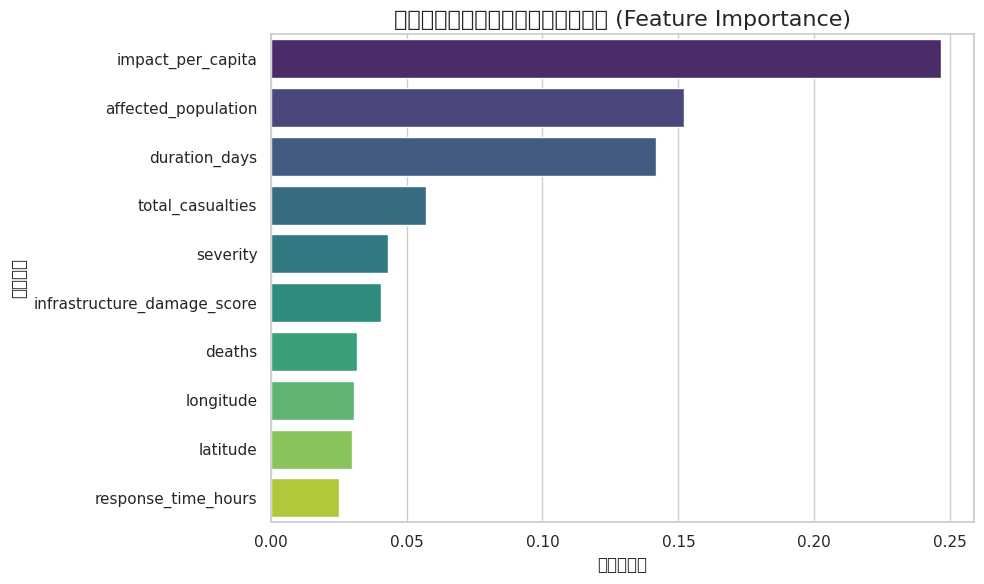

In [19]:
# 畫出特徵重要性圖表 (已修正 seaborn 警告寫法)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importances.head(10), 
    x='Importance', 
    y='Feature', 
    hue='Feature',      # 指定用 Feature 來決定顏色
    palette='viridis', 
    legend=False        # 關閉自動產生的圖例
)

plt.title('預測極端氣候災損：前十大關鍵特徵 (Feature Importance)', fontsize=16)
plt.xlabel('重要性分數', fontsize=12)
plt.ylabel('特徵名稱', fontsize=12)
plt.tight_layout()
plt.show()